### Setup

In [1]:
%load_ext autoreload
%autoreload --print 3

In [2]:
import jax.random as jr
jr.KeyArray = jr.PRNGKey
import shape_norm

from shape_norm.io import loaders
from shape_norm.models import joint
from shape_norm import config
from shape_norm.models import instantiation, setup, pose, morph, util as model_util
from shape_norm import fitting
from shape_norm.fitting import em
from shape_norm.io import alignment, features
from shape_norm.io.armature import Armature
from shape_norm.fitting import methods
from shape_norm.fitting import scans
from shape_norm.pca import fit_with_center, CenteredPCA, PCAData
from shape_norm.io.dataset import PytreeDataset
from shape_norm.io.dataset_refactor import Dataset, SessionMetadata
from shape_norm.models.morph.lowrank_affine import LRAParams, model as lra_model
from shape_norm.viz import styles

from blscale_loader import loader, linear_skeletal as blscale_ls

from collections import defaultdict
from shape_norm.viz import util as vu
from scipy import spatial
import itertools as iit
import numpy as np
import re
from functools import reduce
import jax
import jax.numpy as jnp
from pprint import pprint
from ruamel.yaml import YAML
import scipy.stats
from sklearn.linear_model import LinearRegression
from pathlib import Path
import matplotlib as mpl
import joblib as jl
import matplotlib.pyplot as plt
from tqdm import tqdm, trange
import itertools as iit
import pandas as pd
import seaborn as sns


In [3]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

plot_dir = '/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v5/f3.1_session-halves'
params_file = "/Users/kaifox/projects/mph/generative_api/test/notebooks/panels/plot_params.yml"

plot_meta = YAML(typ='safe').load(open(params_file, 'r'))
colors, plotter = styles.init_plt(plot_dir, style='default', fmt = 'pdf', **plot_meta['savefig'])
plt.rcParams.update(plot_meta['rc'])
plot_root = Path(plotter.plot_dir)

### Supporting funcs

#### General supporting funcs

In [4]:
import jax.random as jr

jr.KeyArray = jr.PRNGKey
import numpy as np
import numpy.linalg as la
from scipy.signal import savgol_filter
import matplotlib.colors as mpl_col

# calculus and statistics
val_and_deriv = lambda x, w=5: (x, savgol_filter(x, w, polyorder=1, deriv=1, axis=0))
vel_acc = lambda x, w=5: val_and_deriv(  # x, shape (t, ..., spatial)
    la.norm(savgol_filter(x, w, polyorder=1, deriv=1, axis=0), axis=-1), w=w
)
cos = lambda a, b: np.clip(
    (a * b).sum(axis=-1) / (la.norm(a, axis=-1) * la.norm(b, axis=-1)), -1, 1
)
cov = lambda x, y: (x * y).mean(axis=-1) - x.mean(axis=-1) * y.mean(axis=-1)
corr = lambda a, b: cov(a, b) / np.sqrt(cov(a, a) * cov(b, b))
coef = lambda a, b: cov(a, b) / cov(a, a)
windowed_cov = lambda x, y, w: cov(
    *np.lib.stride_tricks.sliding_window_view(
        np.pad(
            np.stack([x, y]),
            ((0, 0), (int(np.ceil((w - 1) / 2)), int(np.floor((w - 1) / 2)))),
        ),
        window_shape=w,
        axis=1,
    )
)

# skeleton functions
bone_locations = lambda keypts, armature: np.stack(
    [
        keypts[..., armature.bones[i, 1], :] - keypts[..., armature.bones[i, 0], :]
        for i in range(len(armature.bones))
    ],
    axis=-2,
)
bone_lengths = lambda keypts, armature: la.norm(
    bone_locations(keypts, armature), axis=-1
)
elevation = (
    lambda arr: (
        np.arccos(cos(arr, arr * np.array([1, 1, 0])[None])) * np.sign(arr[:, 2])
    )
    * 180
    / np.pi
)
rotation = (
    lambda arr: (
        np.arccos(cos(arr, arr * np.array([1, 0, 1])[None])) * np.sign(arr[:, 1])
    )
    * 180
    / np.pi
)
short_bone_names = lambda armature: [
    armature.keypoint_names[int(i)] for i, j in armature.bones
]
long_bone_names = lambda armature: [
    f"{armature.keypoint_names[int(i)]}-{armature.keypoint_names[int(j)]}"
    for i, j in armature.bones
]


# model manipulation
def lra_anchor_poses(params, magnitudes=90):
    L = params.n_dims

    if isinstance(magnitudes, (int, float)):
        magnitudes = magnitudes * np.ones(L)

    # (n_bodies, n_dims, 1)
    anchors = (params.offset + params.offset_updates).reshape(params.n_bodies, -1, 1)
    # (n_bodies, n_dims, n_modes + 1)
    anchors = np.concatenate(
        [
            anchors,
            anchors + magnitudes[None, None] * (params.modes + params.mode_updates),
        ],
        axis=-1,
    )

    return anchors


def lra_induced_anchors(dataset, config, params, magnitudes, n_neighbors):
    from kpsn.models import util
    from kpsn.models.morph.lowrank_affine import model

    anchors = lra_anchor_poses(params, magnitudes)
    ref_data = dataset.get_session(dataset.ref_session)
    ref_anchor_diff = (
        ref_data[..., None]
        - anchors[None, dataset.session_body_id(dataset.ref_session)]
    )
    near_anchors_ix = np.array(
        [
            la.norm(ref_anchor_diff[..., j], axis=(-1)).argsort(axis=0)[:n_neighbors]
            for j in range(anchors.shape[-1])
        ]
    )
    induced_anchors = util.induced_reference_keypoints(
        dataset,
        config,
        model,
        params,
        include_reference=True,
        ref_frames=ref_data[near_anchors_ix].mean(axis=1),
    )

    return induced_anchors



### plotting


def plot_mouse_3d(
    frame,
    ax,
    armature,
    elev,
    rot,
    colors=None,
    bone_n=40,
    point_size=10,
    line_size=2,
    line_colors=None,
    point_kws={},
    line_kws={},
    boundary=True,
    set_aspect=True,
    label = None
):
    """all keys in point kws should be present in line kws"""

    if colors is None:
        import seaborn as sns

        colors = mpl_col.to_rgba(sns.color_palette("Blues", 10 + frame.shape[0])[10:])
    if line_colors is None:
        line_colors = colors
    colors = np.array([mpl_col.to_rgba(x) for x in colors])
    line_colors = np.array([mpl_col.to_rgba(x) for x in line_colors])
    point_kws = {
        **dict(
            linewidths=np.array([0] * armature.n_kpts),
        ),
        **point_kws,
    }
    line_kws = {
        **dict(
            linewidths=np.array([0] * armature.n_kpts),
        ),
        **line_kws,
    }

    # --- points

    x, y, z, c, s = [], [], [], [], []
    x.append(frame[:, 0])
    y.append(frame[:, 1])
    z.append(frame[:, 2])
    c.append(colors)
    s.append([point_size] * armature.n_kpts)
    kws = {k: [] for k in point_kws}
    concat_keys = []
    for k, v in point_kws.items():
        if np.array(v).shape[:1] == (armature.n_kpts,):
            concat_keys.append(k)
            kws[k].append(v)
        else:
            kws[k] = v

    x = np.concatenate(x)
    y = np.concatenate(y)
    z = np.concatenate(z)
    c = np.concatenate(c)
    s = np.concatenate(s)
    for k, v in kws.items():
        if k in concat_keys:
            kws[k] = np.concatenate(kws[k])
    point_artist = ax.scatter(x, y, z, c=c, s=s, depthshade=False, **kws)

    # --- "lines"

    x, y, z, c, s = [], [], [], [], []
    kws = {k: [] for k in line_kws}
    concat_keys = []
    for i, (ch, pa) in enumerate(armature.bones):
        x.append(np.linspace(frame[ch, 0], frame[pa, 0], bone_n)[1:-1])
        y.append(np.linspace(frame[ch, 1], frame[pa, 1], bone_n)[1:-1])
        z.append(np.linspace(frame[ch, 2], frame[pa, 2], bone_n)[1:-1])
        c.append(np.full([bone_n - 2, 4], line_colors[ch]))
        s.append(np.full([bone_n - 2], line_size))
        for k, v in line_kws.items():
            if np.array(v).shape[:1] == (armature.n_kpts,):
                concat_keys.append(k)
                kws[k].append(np.full((bone_n - 2,) + np.array(v).shape[1:], v[ch]))
            else:
                kws[k] = v
    x = np.concatenate(x)
    y = np.concatenate(y)
    z = np.concatenate(z)
    c = np.concatenate(c)
    s = np.concatenate(s)
    for k, v in kws.items():
        if k in concat_keys:
            kws[k] = np.concatenate(kws[k])

    line_artist = ax.scatter(x, y, z, c=c, s=s, depthshade=False, **kws)

    ax.view_init(elev, rot)

    ax.grid(False)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.set_ticks([])
    ax.yaxis.set_ticks([])
    ax.zaxis.set_ticks([])
    if not boundary:
        ax.xaxis.pane.set_linewidth(0)
        ax.yaxis.pane.set_linewidth(0)
        ax.zaxis.pane.set_linewidth(0)
        ax.xaxis.line.set_linewidth(0)
        ax.yaxis.line.set_linewidth(0)
        ax.zaxis.line.set_linewidth(0)

    
    # use a.set_box_aspect to make the aspect equal to the ratio of the limits
    if set_aspect:
        xrng = np.ptp(ax.get_xlim())
        yrng = np.ptp(ax.get_ylim())
        zrng = np.ptp(ax.get_zlim())
        ax.set_box_aspect([xrng, yrng, zrng])

    return point_artist, line_artist

#### Raw keypoint data supporting funcs

In [5]:
def raw_data_armature_meta():
    """Organize metadata on keypoints and skeleton of mouse data."""
    names = [
        'shldr', 'back', 'hips', 't_base', 't_tip', 'head',
        'l_ear', 'r_ear', 'nose', 'lr_knee', 'lr_foot',
        'rr_knee', 'rr_foot', 'lf_foot', 'rf_foot']
    parents = dict(zip(names, [
        'back', 'hips', None, 'hips', 't_base', 'shldr',
        'head', 'head', 'head', 'hips', 'lr_knee',
        'hips', 'rr_knee', 'shldr', 'shldr']))
    keypt_ix = lambda name: names.index(name)
    bones = np.array([(keypt_ix(c), keypt_ix(p)) for c, p in parents.items() if p])
    root = keypt_ix("shldr")
    bones = blscale_ls.reroot(bones, root)
    bones = bones[np.argsort(bones[:, 0])]
    return names, parents, bones, root

def raw_data_armature_meta_no_tail():
    """Organize metadata on keypoints and skeleton of mouse data."""
    names = [
        'shldr', 'back', 'hips', 't_base', 'head',
        'l_ear', 'r_ear', 'nose', 'lr_knee', 'lr_foot',
        'rr_knee', 'rr_foot', 'lf_foot', 'rf_foot']
    parents = dict(zip(names, [
        'back', 'hips', None, 'hips', 'shldr',
        'head', 'head', 'head', 'hips', 'lr_knee',
        'hips', 'rr_knee', 'shldr', 'shldr']))
    keypt_ix = lambda name: names.index(name)
    bones = np.array([(keypt_ix(c), keypt_ix(p)) for c, p in parents.items() if p])
    root = keypt_ix("shldr")
    bones = blscale_ls.reroot(bones, root)
    bones = bones[np.argsort(bones[:, 0])]
    return names, parents, bones, root

keypt_names = [
    'shldr',
    'back',
    'hips',
    't_base',
    'head',
    'l_ear',
    'r_ear',
    'nose',
    'lr_knee',
    'lr_foot',
    'rr_knee',
    'rr_foot',
    'lf_foot',
    'rf_foot'
]
keypt_ix = lambda k: keypt_names.index(k)
_names, _parents, _bones, _root = raw_data_armature_meta_no_tail()
arms = Armature(_names, _bones, _root, anterior=[], posterior=[])

# bone_names = [f'{keypt_names[i]}-{keypt_names[j]}' for i, j in armature.bones]
bone_names = [
    'hi back', #  'back-shldr',
    'lo back', #  'hips-back',
    'rump', #  't_base-hips',
    'neck', #  'head-shldr',
    'left ear', #  'l_ear-head',
    'right ear', #  'r_ear-head',
    'head', #  'nose-head',
    'left hindlimb', #  'lr_knee-hips',
    'left hind foot', #  'lr_foot-lr_knee',
    'right hindlimb', #  'rr_knee-hips',
    'right hind foot', #  'rr_foot-rr_knee',
    'left forelimb', #  'lf_foot-shldr',
    'right forelimb' #  'rf_foot-shldr'
]
keypt_parent = lambda ix, armature = arms: armature.bones[armature.bones[:, 0] == ix, 1][0]
has_parent = lambda ix, armature = arms: np.any(armature.bones[:, 0] == ix)
bone_ix = lambda keypt_ix, armature = arms: np.where(armature.bones[:, 0] == keypt_ix)[0][0]

joints = np.array([(child, parent, keypt_parent(parent)) for child, parent in arms.bones if has_parent(parent)])
joint_names = [f'{keypt_names[c]}-{keypt_names[p]}-{keypt_names[g]}' for c, p, g in joints]
joint_names = [
'back', #  'hips-back-shldr',
'hips', #  't_base-hips-back',
'left ear', #  'l_ear-head-shldr',
'right ear', #  'r_ear-head-shldr',
'head', #  'nose-head-shldr',
'left hindlimb', #  'lr_knee-hips-back',
'left hind foot', #  'lr_foot-lr_knee-hips',
'right hindlimb', #  'rr_knee-hips-back',
'right hind foot', #  'rr_foot-rr_knee-hips'
]

short_names = [keypt_names[i] for i, j in arms.bones]
full_joint_angles_func = (
    lambda kpts, joint_ix, joints: 180
    / np.pi
    * np.arccos(
        np.clip(
            cos(
                kpts[:, joints[joint_ix, 0], :] - kpts[:, joints[joint_ix, 1], :],
                kpts[:, joints[joint_ix, 2], :] - kpts[:, joints[joint_ix, 1], :],
            ),
            -1,
            1,
        )
    )
)
joint_angles = lambda kpts, joint_ix: full_joint_angles_func(kpts, joint_ix, joints)

#### Dataset functions

In [6]:
_with_match = lambda test, pattern, f: f(m) if (m := re.search(pattern, test)) else None
_name_func = lambda path, *a: _with_match(
    path, r"(?:/.*)+/\d{2}_\d{2}_\d{2}_(\d+wk_m\d+)\.npy",
    lambda m: f"{m.group(1)}")

def full_ontogeny_data(data_dir, session_filter=None, ref_session=None):
    _sources = dict(map(lambda x: (_name_func(str(x)),) * 2, data_dir.glob(f"*.npy")))
    if session_filter is not None:
        _sources = {k: v for k, v in _sources.items() if session_filter(k)}
    ont_keypoints, _ = loader.from_sources_dict(
        data_dir,
        _sources,
        extension='.npy',
        name_func=_name_func,
    )
    names, parents, _, _ = raw_data_armature_meta()

    if ref_session is None:
        ref_session = list(ont_keypoints.keys())[0]

    project_config_kws = {
        "session_names": ont_keypoints.keys(),
        "bodies": {s: f'b-{s}' for s in ont_keypoints},
        "ref_session": ref_session,
        "keypoint_names": names,
        "keypoint_parents": parents,
    }

    return project_config_kws, ont_keypoints

def full_ontogeny_data_aligned(data_dir, session_filter=None, use_keypoints=None, scale_ntt=False):
    project_config_kws, ont_keypoints = full_ontogeny_data(data_dir, session_filter)
    if use_keypoints is None:
        use_keypoints = project_config_kws['keypoint_names']
    dataset = loaders.arrays.from_arrays(ont_keypoints, dict(
        type='arrays',
        subsample=None,
        subsample_to=None,
        ref_session=project_config_kws['ref_session'],
        sessions={s: dict(body=b) for s, b in project_config_kws['bodies'].items()},
        keypoint_names=project_config_kws['keypoint_names'],
        use_keypoints=use_keypoints,
        anterior=None,
        posterior=None,
        invert_axes=None,
    ))
    aligned, align_inv = alignment.align(dataset, dict(
        type='sagittal',
        origin='hips',
        anterior='head',
        rescale=scale_ntt,
        rescale_mode='session',
    ))
    return aligned, dataset, align_inv
    

#### Plotting

In [7]:
def getc(spec):
    try:
        from cmap import Colormap, Color
        try:
            return Color(spec)
        except ValueError as e:
            stop = spec.split(':')[-1]
            if stop.startswith('.'):
                stop = float(stop)
            else:
                stop = int(stop)
            cm = Colormap(':'.join(spec.split(':')[:-1]))
            return cm(stop)
    except ImportError:
        return spec
    
    
plot_meta = YAML(typ='safe').load(open(params_file, 'r'))
age_pal = {k: getc(c) for k, c in plot_meta['colors']['age'].items()}
bhv_pal = {k: getc(c) for k, c in plot_meta['colors']['bhv'].items()}

#### Ethogram supporting funcs

In [8]:
bhv_keys = plot_meta['behavior']["keys"]
bhv_names = plot_meta['behavior']["names"]

#### Timeseries supporting funcs

In [9]:
# --- Rolling-mean time series, groupwise stripplot utiliies ---

def rolling_line(ax, x, ys, window, color, lighten = 0, **kws):
    ydf = pd.DataFrame(np.array(ys).T, index = x).rolling(window).mean()
    y = ydf.mean(axis = 1).iloc[::window // 2]
    yerr = ydf.std(axis = 1).iloc[::window // 2]
    ax.plot(y, color = color, **kws)
    ax.fill_between(y.index, y - yerr, y + yerr, color = vu.lighten(color, lighten), alpha = 0.3, linewidth = 0)
    
def agewise_stripstat(func, groups, order, expand = True):
    ret = [np.array([func(s) for s in groups[k]]) for k in order]
    if expand:
        ret = vu.expand_groups(ret, order)
    return ret

def stripstat(func, keys):
    return [np.array([func(s) for s in keys])]


def group_and_summary_strips(
    ax,
    func,
    groups,
    order,
    all_keys,
    summary_color,
    group_colors,
    x_ofs=3,
    **kws
):
    vu.grouped_stripplot(
        agewise_stripstat(func, groups, order),
        ax=ax,
        colors=group_colors,
        **{'offset': False, 'lighten_points': 0.5, **kws},
    )
    vu.grouped_stripplot(
        stripstat(func, all_keys),
        x=[-x_ofs],
        ax=ax,
        colors=summary_color,
        jitter=0.2,
        **{'offset': False, 'lighten_points': 0.5, **kws},
    )

    ax.set_xticks([-x_ofs] + list(range(len(order))))
    ax.set_xlim([-x_ofs - 2, len(order) + 1])
    ax.set_xticklabels([""] * (len(order) + 1))

#### Prediction and variance explained funcs

In [10]:

def mean_predictor(masks, ys, return_means=False):
    """
    Calculates the mean predictor based on the given masks and ys.

    Predictions are made according to the average value of the target sequence
    while each mask is True. When no mask is True, the prediction falls back on
    the overall mean of the target sequence.

    Parameters:
    masks (dict or list): A dictionary or list of masks, where each mask is a
    boolean array of the same length as the target sequence, and no two masks
    are True at the same time.
    ys (array-like): An array-like object containing the target sequence.
    
    Returns:
    array-like: The mean predictor calculated based on the masks and ys.
    """

    if isinstance(masks, dict):
        masks = list(masks.values())
    masks = [np.array(m) for m in masks]
    means = np.array([ys[m].mean(axis = 0) for m in masks] + [ys.mean(axis = 0)])
    masks = masks + [~np.any(masks, axis = 0)]
    ixs = np.argmax(masks, axis = 0)
    if return_means:
        means
    return means[ixs]


def concat_with_masks(arrays):
    """
    Concatenate arrays and return masks corresponding to original identity.
    """
    masks = [
        np.full([len(a), len(arrays)], np.eye(len(arrays), dtype = bool)[[i]])
        for i, a in enumerate(arrays)
    ]
    return np.concatenate(masks).T, np.concatenate(arrays)

def expl_var(y_true, y_pred):
    """
    Calculate the explained variance of the prediction.
    """
    return 1 - np.var(y_true - y_pred, axis = 0) / np.var(y_true, axis = 0)

### Load data (new)

#### Mouse data

In [128]:
# --- load keypoints and align
data_dir = "/Users/kaifox/projects/mph/data_explore/data"
use_kpts = [
    "shldr",
    "back",
    "hips",
    "t_base",
    "head",
    "l_ear",
    "r_ear",
    "nose",
    "lr_knee",
    "lr_foot",
    "rr_knee",
    "rr_foot",
    "lf_foot",
    "rf_foot",
]
session_filter = lambda s: re.search(r"(\d+)wk", s).group(1) not in ["9", "12"]
ont_dataset, unaligned_dataset, align_inv = full_ontogeny_data_aligned(
    Path(data_dir),
    session_filter=session_filter,
    use_keypoints=use_kpts,
)
obs_keypts = {s: ont_dataset.get_session(s) for s in ont_dataset.sessions}
unaligned = {
    s: unaligned_dataset.get_session(s) for s in unaligned_dataset.sessions
}


# --- organize metadata and simple transforms of the data

sessions = ont_dataset.sessions
src_sess = "24wk_m0"
src_keypts = obs_keypts[src_sess]
fps = 29.97
session_length = {s: len(obs_keypts[s]) for s in sessions}

centroids = {
    s: align_inv["centroid"][slice(*ont_dataset.get_slice(s))] for s in sessions
}
velocities = {
    s: la.norm(
        np.diff(centroids[s], axis=0),
        axis=-1,
    )
    for s in sessions
}

bl = {
    s: la.norm(bone_locations(obs_keypts[s], arms), axis=-1) for s in sessions
}
ja = {
    s: np.stack(
        [joint_angles(obs_keypts[s], i) for i in range(len(joints))], axis=-1
    )
    for s in sessions
}

age_groups = defaultdict(list)
for s in sessions:
    age_groups[s.split("_")[0].rstrip("wk")].append(s)
age_groups = dict(age_groups)
ages = sorted(list(age_groups.keys()), key=lambda x: int(x))

print("Age groups:")
pprint(age_groups)

Loading keypoints: 100%|███████████████| 36/36 [00:00<00:00, 327.13it/s]


Age groups:
{'24': ['24wk_m1', '24wk_m0', '24wk_m2', '24wk_m3', '24wk_m4', '24wk_m5'],
 '3': ['3wk_m1', '3wk_m0', '3wk_m2', '3wk_m3'],
 '5': ['5wk_m6',
       '5wk_m7',
       '5wk_m5',
       '5wk_m4',
       '5wk_m0',
       '5wk_m1',
       '5wk_m3',
       '5wk_m2'],
 '52': ['52wk_m0', '52wk_m1', '52wk_m3', '52wk_m2', '52wk_m5', '52wk_m4'],
 '7': ['7wk_m3', '7wk_m2', '7wk_m0', '7wk_m1'],
 '72': ['72wk_m2',
        '72wk_m3',
        '72wk_m1',
        '72wk_m0',
        '72wk_m4',
        '72wk_m5',
        '72wk_m7',
        '72wk_m6']}


#### Ethogram data & bins

In [21]:
bhv_labels = jl.load('/Users/kaifox/projects/mph/data_explore/data/moont_scalar-classifier-behaviors.p')
bhv_masks = {k: bhv_labels['masks'][n] for k, n in bhv_keys.items()}
nolabel_mask = {s: ~reduce(np.bitwise_or, [bhv_masks[k][s] for k in bhv_keys]) for s in sessions}


In [32]:
# --- set up bounds of session halves and time bins

n_bins = 20
splits_to_slices = lambda x: [slice(a, b) for a, b in zip(x[:-1], x[1:])]
bin_slices = {
    s: splits_to_slices(
        np.linspace(0, session_length[s], n_bins + 1).astype(int)
    )
    for s in sessions
}
approx_slice_lens = np.mean(
    [session_length[s] / (n_bins + 1) for s in sessions]
)
slice_times = (np.arange(1, n_bins + 1) * approx_slice_lens) / fps / 60

frame_times = (
    np.arange(0, min([session_length[s] for s in sessions])) / fps / 60
)
min_nframes = len(frame_times)
half_slices = [
    slice(0, len(frame_times) // 2),
    slice(len(frame_times) // 2, None),
]

### Load data (old)

In [5]:
# kws = dict(rescale = True, 
#     output_indep =  False,
#     subsample = None,
#     origin_keypt = 'hips',
#     path = '../../../data_explore/data',
#     age_blacklist = [9, 12],
#     whitelist = None,
#     split = None,
#     jitter = None
# )
# (N, M), gt_obs, metadata = npy_keypts.generate(dict(
#     **kws))

# sessions = metadata['session_slice'].keys()
# slices = metadata['session_slice']
# src_sess = '24wk_m0'
# obs_keypts = {s: gt_obs.keypts[slices[s]].reshape([-1, 14, 3]) for s in sessions}
# session_length = {s: len(obs_keypts[s]) for s in sessions}
# unaligned = {s: inverse_saggital_align(obs_keypts[s], metadata['centroid'][s], metadata['rotation'][s]) for s in sessions}
# src_kpts = obs_keypts[src_sess]
# age_groups = defaultdict(list)
# for s in sessions:
#     age_groups[s.split('_')[0].rstrip('wk')].append(s)
# age_groups = dict(age_groups)
# ages = sorted(list(age_groups.keys()), key = int)
# fps = 30

In [6]:
# bhv_labels = jl.load('../../../data_explore/data/moont_scalar-classifier-behaviors.p')
# bhv_masks = {k: bhv_labels['masks'][v] for k, v in bhv_keys.items()}
# neither_mask = {s: ~reduce(np.bitwise_or, [bhv_masks[k][s] for k in bhv_keys]) for s in sessions}
# velocities = {s: la.norm(np.diff(metadata['centroid'][s], axis = 0), axis = -1) for s in sessions}

In [7]:
# n_bins = 20
# splits_to_slices = lambda x: [slice(a, b) for a, b in zip(x[:-1], x[1:])]
# bin_slices = {
#     s: splits_to_slices(np.linspace(0, session_length[s], n_bins + 1).astype(int))
#     for s in sessions
# }
# approx_slice_lens = np.diff([np.linspace(0, session_length[s], n_bins + 1).astype(int) for s in sessions], axis = 1).mean(axis = 0)
# slice_times = (np.cumsum(approx_slice_lens) - approx_slice_lens[0]) / fps / 60

# frame_times = np.arange(0, min([session_length[s] for s in sessions])) / fps / 60
# min_nframes = len(frame_times)
# half_slices = [slice(0, len(frame_times) // 2), slice(len(frame_times) // 2, None)]

### 1. Time courses of velocity, locomotion, rearing, (or other if good ratios)

#### binned: too choppy to easily make sense of

In [34]:

binned_mean = lambda bins, arrs: {s: [arrs[s][slc].mean() for slc in bins[s]] for s in bins}
binned_vel = binned_mean(bin_slices, velocities)
binned_bhvs = {k: binned_mean(bin_slices, bhv_masks[k]) for k in bhv_keys}



In [35]:
def meanstd_line(ax, x, ys, color, lighten = 0):
    y = np.array(ys).mean(axis = 0)
    yerr = np.array(ys).std(axis = 0)
    ax.plot(x, y, color = color, lw = 1.)
    ax.fill_between(x, y - yerr, y + yerr, color = vu.lighten(color, lighten), alpha = 0.3, linewidth = 0)

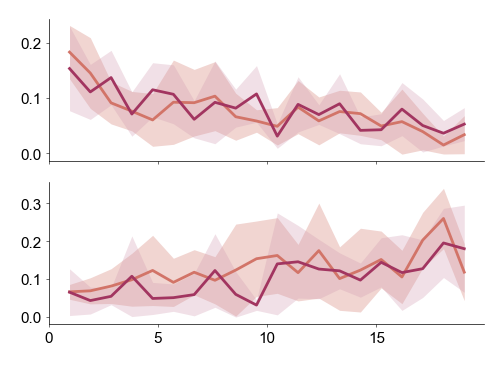

In [39]:
plot_sess = ["5", "52"]
lighten = [0, 0.5]
linewidth = [1.5, 1]

fig, ax = plt.subplots(2, 1, figsize=(2.5, 1.8))

for i, (a, lt) in enumerate(zip(plot_sess, lighten)):
    l = age_groups[a]
    loc = [binned_bhvs["loco"][s] for s in l]
    hdr = [binned_bhvs["raise"][s] for s in l]

    meanstd_line(ax[0], slice_times, loc, age_pal[a], lt)
    meanstd_line(ax[1], slice_times, hdr, age_pal[a], lt)

for a in ax:
    a.set_xticks([0, 5, 10, 15])
for a in ax[:-1]:
    a.set_xticklabels(["", "", "", ""])

    

plotter.finalize(fig, None)

#### rolling

/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


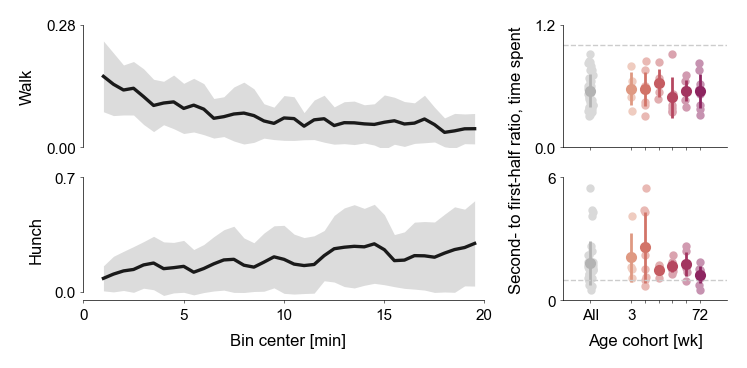

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v5/f3.1_session-halves/timecourse-bhvs.pdf')

In [67]:
plot_sess = ["24wk_m4"]
lighten = [0.5, 0.5]
linewidth = [1.2, 1]

fig, ax = plt.subplots(2, 2, figsize=(3.7, 1.8), width_ratios=[2.5, 1])
summ_ax = ax[:, 1]
time_ax = ax[:, 0]

ax = time_ax
for i, (s, lt, lw) in enumerate(zip(plot_sess, lighten, linewidth)):
    l = sessions
    loc = [bhv_masks["loco"][s][:min_nframes] for s in l]
    hdr = [bhv_masks["hunch"][s][:min_nframes] for s in l]
    a = s.split("_")[0].rstrip("wk")

    rolling_line(ax[0], frame_times, loc, 1800, colors.neutral, lt, lw=lw)
    rolling_line(ax[1], frame_times, hdr, 1800, colors.neutral, lt, lw=lw)

for a in ax:
    a.set_xticks([0, 5, 10, 15, 20])
    a.set_ylim(0, None)
for a in ax[:-1]:
    a.set_xticklabels(["", "", "", "", ""])
vu.nticks(ax, 2, x=False)
vu.round_limits(ax, 0.6, x=False, fixed_vmin=0)

ax[0].set_ylabel(bhv_names["loco"])
ax[1].set_ylabel(bhv_names["hunch"])
ax[-1].set_xlabel("Bin center [min]")
ax[0].set_xticks([])
ax[0].spines['bottom'].set_visible(False)
ax[1].set_yticks(ax[1].get_yticks())
ax[1].set_ylim(-0.05, ax[1].get_ylim()[1])
sns.despine(ax = ax[1], trim=True)

ax = summ_ax
half_rto = (
    lambda k: lambda s: bhv_masks[k][s][half_slices[1]].mean()
    / bhv_masks[k][s][half_slices[0]].mean()
)

groupstrip_kws = dict(
    groups=age_groups,
    order=ages,
    all_keys=sessions,
    summary_color='.7',
    group_colors=age_pal,
    x_ofs=3,
)

group_and_summary_strips(
    ax[0],
    half_rto("loco"),
    **groupstrip_kws    
)

group_and_summary_strips(
    ax[1],
    half_rto("hunch"),
    **groupstrip_kws
)

for a in ax:
    a.axhline(1, color=colors.subtle, lw=0.5, ls="--")

ax[-1].set_xticklabels(["All"] + [ages[0]] + [""] * (len(ages) - 2) + [ages[-1]])
vu.nticks(ax, 2, x=False)
vu.round_limits(ax, 0.6, x=False, fixed_vmin=0)
ax[0].set_ylabel(" ")
ax[-1].set_xlabel("Age cohort [wk]")
plt.tight_layout()
ax[0].text(-0.33, -0.1, "Second- to first-half ratio, time spent", va = 'center', rotation=90, transform=ax[0].transAxes)


plotter.finalize(fig, 'timecourse-bhvs', despine=False, tight=False)

In [ ]:
kws = dict(
    lighten_points = 0.5
)
vu.grouped_stripplot(
    agewise_stripstat(half_rto('loco')),
    ax = ax[0], colors = colors.age_pal,
    **kws,
)
vu.grouped_stripplot(
    stripstat(half_rto('loco')),
    x = [-3], ax = ax[0], colors = 'k',
    jitter = 0.2,
    **kws
)

vu.grouped_stripplot(
    agewise_stripstat(half_rto('raise')),
    ax = ax[1], colors = colors.age_pal,
    **kws,
)
vu.grouped_stripplot(
    stripstat(half_rto('raise')),
    x = [-3], ax = ax[1], colors = 'k',
    jitter = 0.2,
    **kws
)

for a in ax:
    
    a.set_xticks([-3] + list(range(len(ages))))
    a.set_xlim([-4.5, len(ages) + 1])
    a.set_xticklabels([''] * (len(ages) + 1))

### 2. Time averaged pose from first and second half

In [291]:
ex_session = '24wk_m0'
mean_pose = {s: [obs_keypts[s][slc].mean(axis = 0) for slc in half_slices] for s in sessions}

../../plots/notebook/panels/v4/f3.1_session-halves/mean-pose-example.pdf


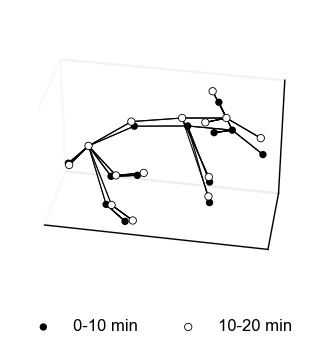

In [295]:
fig, ax = plt.subplots(1, 1, figsize = (1.7, 1.8), subplot_kw={"projection":'3d'})
arms = skeleton.default_armature
kws = lambda c, e, r, lw, label: dict(
    armature = arms,
    elev = e, rot = r,
    colors = [mpl_col.to_rgb(c)] * 14,
    line_colors = [mpl_col.to_rgb('k')] * 14,
    bone_n = 100,
    boundary = True,
    point_size = 7,
    line_size = 0.2,
    point_kws = {'lw': np.array([lw] * 14), 'edgecolors': np.array([(0, 0, 0)] * 14), 'zorder': 3, 'label': label},
    line_kws = {'lw': np.array([0] * 14), 'edgecolors': np.array([(0, 0, 0)] * 14), 'zorder': 1}
)

plot_mouse_3d(mean_pose[ex_session][0], ax, **kws('k', 35, -80, 0, '0-10 min'))
plot_mouse_3d(mean_pose[ex_session][1], ax, **kws('w', 35, -80, 0.3, '10-20 min'))

vu.legend(ax, loc = 'lower center', ncol = 2, bbox_to_anchor = (0.5, -0.2))


plotter.finalize(fig, 'mean-pose-example', save = True, transparent = True, despine = False)

In [293]:
not_hips = [i for i in range(14) if keypt_names[i] != 'hips']
pose_point_dists = {s: la.norm(np.diff(mean_pose[s], axis = 0)[0], axis = -1)[not_hips] for s in sessions}

/Users/kaifox/projects/mph/mph/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


../../plots/notebook/panels/v4/f3.1_session-halves/mean-pose-keypt-dists.pdf


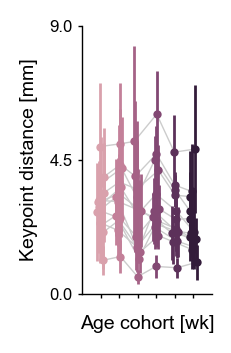

In [294]:
fig, ax = plt.subplots(1, 1, figsize=(1.2, 1.8))
for i in range(arms.n_kpts - 1):
    stripdata = agewise_stripstat(lambda s: pose_point_dists[s][i])
    meanline = [np.mean([a for a in l if a.size > 1]) for l in stripdata.values()]
    x = vu.jitter_points(np.arange(len(ages)), scale = 0.2)
    ax.plot(x, meanline, color=colors.subtle, lw=0.5, zorder = -1)
    vu.grouped_stripplot(
        stripdata,
        x = x,
        xticks = "",
        ax=ax,
        colors=colors.age_pal,
        offset=False,
        jitter=0.05,
        # lighten_points=0.6,
        points = False,
        points_kw=dict(zorder = -2),
        errorbar_kw=dict(lw=0.5)
    )
ax.set_xticks(np.arange(len(ages)))
ax.set_xticklabels([''] * len(ages))
ax.set_xlim(-1, len(ages))
ax.set_ylabel('Keypoint distance [mm]')
ax.set_xlabel('Age cohort [wk]')

vu.nticks(ax, 3, x = False)
# vu.round_limits(ax, 1.4, x=False, fixed_vmin = 0)
ax.set_ylim(0, 9)


plotter.finalize(fig, 'mean-pose-keypt-dists', save = True, transparent = True, despine = False)
    

[3.146347459878244,
 3.106702099267018,
 2.8030747750184988,
 2.5848600474356513,
 2.051338971107062,
 1.8648945433008994]

### g. Behavior biases in distances and joint angles

In [8]:
bl = {
    s: la.norm(bone_locations(obs_keypts[s], skeleton.default_armature), axis = -1)
    for s in sessions
}
ja = {
    s: np.stack([joint_angles(obs_keypts[s], i) for i in range(len(joints))], axis = -1)
    for s in sessions

}

In [288]:
plot_bhv = ['loco', 'rear', 'turn', 'hunch', 'raise']
plot_bones = ['Lower back', 'Forelimb mean', "Back curvature [deg]"]
subsample = 10
all_bl = np.concatenate([bl[s] for s in sessions])
all_ja = np.concatenate([ja[s] for s in sessions])
null_mask = {s: np.ones(session_length[s], dtype = bool) for s in sessions}
all_masks = {
    k: np.concatenate([m[s] for s in sessions])
    for k, m in list(bhv_masks.items()) + [('na', neither_mask), ('none', null_mask)]
}
z_outliers = lambda x, z = 3: np.abs(scipy.stats.zscore(x)) < z
plot_data = [
    all_bl[:, bone_names.index('lo back')],
    all_bl[:, [bone_names.index('left forelimb'), bone_names.index('right forelimb')]].mean(axis = 1),
    180 - all_ja[:, joint_names.index('back')]
]
bone_dists = {k: [
    plot_data[i][z_outliers(plot_data[i]) & m]
    for i in range(len(plot_data))
] for k, m in all_masks.items()}

../../plots/notebook/panels/v4/f3.1_session-halves/bone-bhv-examples.pdf


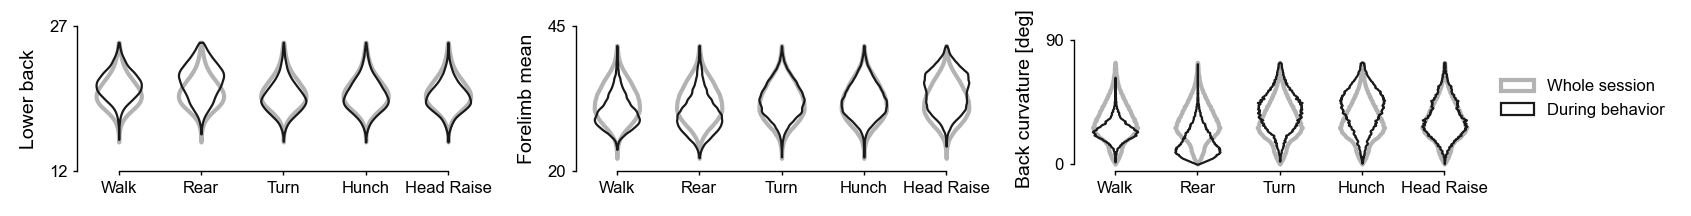

In [297]:
fig, ax = plt.subplots(1, 3, figsize=(8.5, 1.1))
# ax[1, 1].set_axis_off()
ax = ax.T.ravel()[[0, 1, 2]]

kws = dict(
    bw = 0.3,
    x = np.arange(len(plot_bhv)),
    errorbar = False,
    jitter = False,
    thumb_bandwidth = True,
    xticks = "",
    width=0.55,
    legend = False,
)

for i in range(3):
    vu.grouped_violins(
        [[bone_dists['none'][i][::subsample]] for b in plot_bhv],
        colors = colors.semisubtle,
        fill_kw = dict(linewidth = 1.5),
        ax = ax[i],
        labels = 'Whole session',
        **kws,
    )

    vu.grouped_violins(
        [[bone_dists[b][i][::subsample]] for b in plot_bhv],
        colors = colors.neutral,
        ax = ax[i],
        labels = 'During behavior',
        **kws
    )

    ax[i].set_ylabel(plot_bones[i])

for i in [0, 1, 2]:
    ax[i].set_xticklabels([bhv_names[b] for b in plot_bhv])
vu.nticks(ax, 2, x = False)
vu.round_limits(ax, 0.6, x=False)
ax[2].set_ylim(-5, None)
ax[2].set_yticks([0, 90])


for a in ax:
    sns.despine(ax = a, trim = True)

vu.legend(ax[2], vu.unique_handles(ax[2]))

plotter.finalize(fig, 'bone-bhv-examples', save = True, transparent = True, despine=False)

### h. (experiment) Variance in *mean* IKD and JAs explained by behavior and age

In [156]:
session_order = [(s, i) for s in sessions for i in [0, 1]]
onehot = lambda n, i: np.array([0] * (i) + [1] + [0] * (n - i - 1))
bhv_order = list(bhv_keys.keys())
bls_mean = np.array([bl[s][half_slices[i]].mean(axis = 0) for (s, i) in session_order])
ages_onehot = np.array([onehot(len(ages), ages.index(re.search(r"(\d+)wk", s).group(1))) for (s, i) in session_order])
half_length = {s: [len(obs_keypts[s][half_slices[i]]) for i in range(2)] for s in sessions}
usage_fracs = np.array([[bhv_masks[k][s][half_slices[i]].sum() / half_length[s][i] for k in bhv_order] for (s, i) in session_order])

def calc_expl_var(X, Y, Xv, Yv):
    reg = LinearRegression().fit(X, Y)
    preds = reg.predict(Xv)
    errs = Yv - preds
    return errs.var(axis = 0) / Yv.var(axis = 0), preds

bhv_expl_var, bhv_preds = calc_expl_var(usage_fracs, bls_mean, usage_fracs, bls_mean)
age_expl_var, age_preds = calc_expl_var(ages_onehot, bls_mean, ages_onehot, bls_mean)

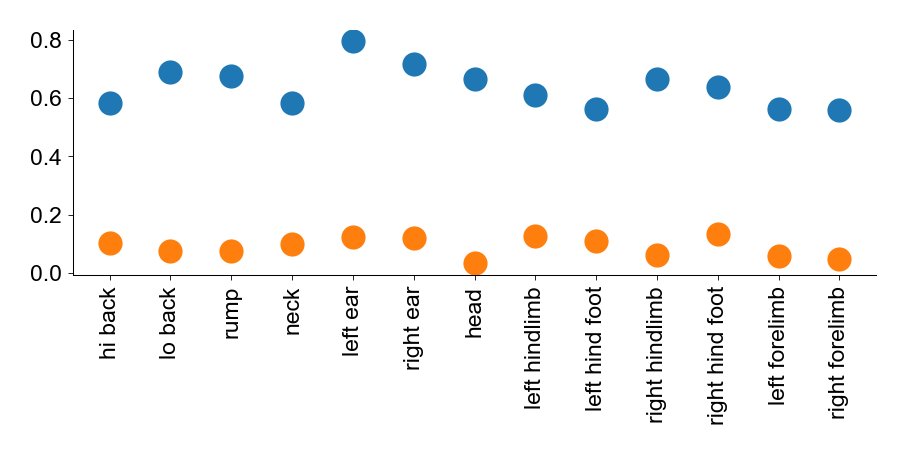

In [132]:
fig, ax = plt.subplots(1, 1, figsize = (3, 1.5), dpi = 150)
ax.plot(bhv_expl_var, 'o')
ax.plot(age_expl_var, 'o')
ax.set_xticks(np.arange(len(bhv_expl_var)))
ax.set_xticklabels(bone_names, rotation = 90)
plotter.finalize(fig, None)

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (2, 1))

plotter.finalize(fig, None)

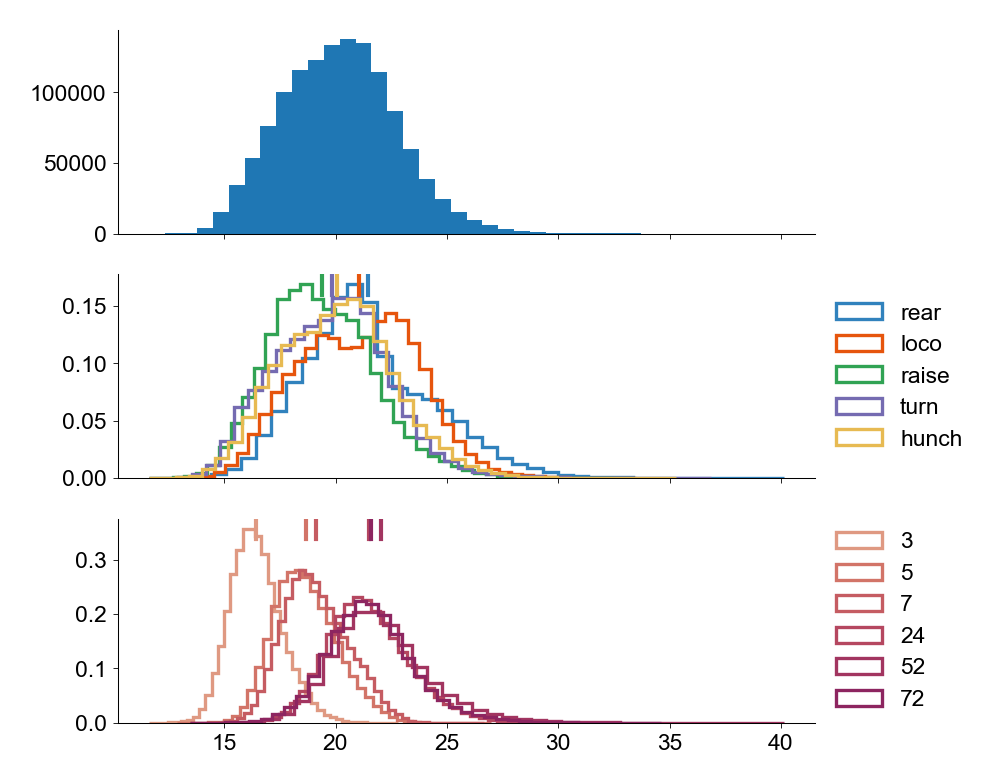

In [154]:
fig, ax = plt.subplots(3,1, figsize = (3, 3), sharex=True, dpi=150)
loback_ix = bone_names.index('lo back')
ax[0].hist(np.concatenate([bl[s][:, loback_ix] for s in sessions]), bins = 40)
for ib in range(5):
    k = bhv_order[ib]
    x = np.concatenate([bl[s][bhv_masks[k][s], loback_ix] for s in sessions])
    ax[1].hist(x, histtype='step', color = bhv_pal[k], bins = 40, label = k, density=True)
    ax[1].axvline(x.mean(), 0.9, 1, lw = 1, color = bhv_pal[k])
for ia, a in enumerate(ages):
    slist = [s for s in sessions if re.search(r"(\d+)wk", s).group(1) == a]
    x = np.concatenate([bl[s][:, loback_ix] for s in slist])
    ax[2].hist(x, histtype='step', color = age_pal[a], bins = 40, label = a,  density=True)
    ax[2].axvline(x.mean(), 0.9, 1, lw = 1, color = age_pal[a])
vu.legend(ax[1])
vu.legend(ax[2])

In [150]:
age_pal

{'3': Color((0.8727, 0.5999, 0.5082)),
 '5': Color((0.8237, 0.4532, 0.4087)),
 '7': Color((0.7744, 0.3621, 0.3826)),
 '24': Color((0.711, 0.2798, 0.3762)),
 '52': Color((0.6363, 0.2064, 0.3777)),
 '72': Color((0.5519, 0.1433, 0.3778))}

### h. Framewise variance explained by behavior and age

In [207]:
all_bl = np.concatenate([bl[s] for s in sessions])
all_masks = {
    k: np.concatenate([m[s] for s in sessions]) for k, m in list(bhv_masks.items())
}
bhv_pred_bls = mean_predictor(all_masks, all_bl)
cohort_bls = [np.concatenate([bl[s] for s in age_groups[a]]) for a in ages]
cohort_mask, cohort_y = concat_with_masks(cohort_bls)
cohort_pred_bls = mean_predictor(cohort_mask, cohort_y)
bhv_expl = expl_var(all_bl, bhv_pred_bls)
cohort_expl = expl_var(cohort_y, cohort_pred_bls)

../../plots/notebook/panels/v4/f3.1_session-halves/bhv-age-expl-var.pdf


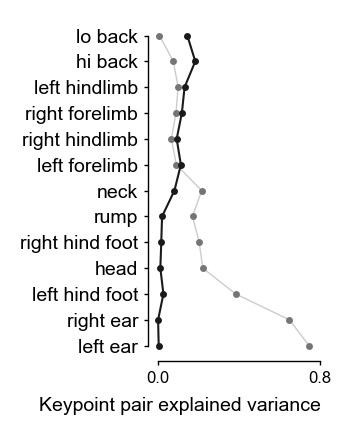

In [254]:
fig, ax = plt.subplots(1, 1, figsize=(1.8, 2.2))
sorting = np.argsort(bhv_expl - cohort_expl)
ax.plot(
    cohort_expl[sorting],
    np.arange(13),
    "-o",
    lw=0.5,
    ms=2.5,
    label="Age cohort",
    color=colors.subtle,
    markerfacecolor=viz.util.lighten(colors.neutral, 0.4),
)
ax.plot(bhv_expl[sorting], np.arange(13), "-o", lw=0.75, ms=2.5, label="Behavior", color=colors.neutral)
ax.set_yticks(np.arange(13))
ax.set_yticklabels([bone_names[i] for i in sorting], fontsize=7)
vu.nticks(ax, 2, y = False)
ax.set_xlim(-0.05, 0.8)
ax.set_xticks([0, 0.8])
sns.despine(ax = ax, trim = True)
ax.set_xlabel("Keypoint pair explained variance" + " " * 20)
# vu.legend(ax, loc = 'lower center', bbox_to_anchor = (0.3, 1), ncol = 2)

plotter.finalize(fig, 'bhv-age-expl-var', save = True, transparent = True, despine = False)

In [214]:
all_ja = np.concatenate([ja[s] for s in sessions])
all_masks = {
    k: np.concatenate([m[s] for s in sessions]) for k, m in list(bhv_masks.items())
}
bhv_pred_jas = mean_predictor(all_masks, all_ja)
cohort_jas = [np.concatenate([ja[s] for s in age_groups[a]]) for a in ages]
cohort_mask, cohort_y = concat_with_masks(cohort_jas)
cohort_pred_jas = mean_predictor(cohort_mask, cohort_y)
bhv_expl_ja = expl_var(all_ja, bhv_pred_jas)
cohort_expl_ja = expl_var(cohort_y, cohort_pred_jas)

../../plots/notebook/panels/v4/f3.1_session-halves/bhv-age-expl-var-ja.pdf


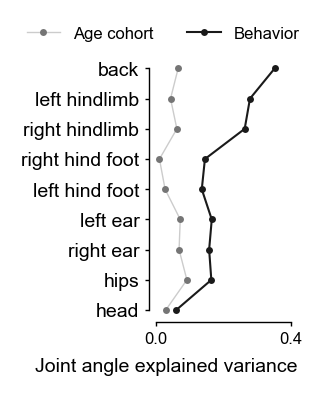

In [299]:
fig, ax = plt.subplots(1, 1, figsize=(1.65, 2))
sorting = np.argsort(bhv_expl_ja - cohort_expl_ja)
ax.plot(
    cohort_expl_ja[sorting],
    np.arange(9),
    "-o",
    lw=0.5,
    ms=2.5,
    label="Age cohort",
    color=colors.subtle,
    markerfacecolor=viz.util.lighten(colors.neutral, 0.4),
)
ax.plot(bhv_expl_ja[sorting], np.arange(9), "-o", lw=0.75, ms=2.5, label="Behavior", color=colors.neutral)
ax.set_yticks(np.arange(9))
ax.set_yticklabels([joint_names[i] for i in sorting], fontsize = 7)
vu.nticks(ax, 2, y = False)
ax.set_xlim(-0.02, 0.4)
ax.set_xticks([0, 0.4])
sns.despine(ax = ax, trim = True)
ax.set_xlabel("Joint angle explained variance" + " " * 20)
vu.legend(ax, loc = 'lower center', bbox_to_anchor = (0.1, 1), ncol = 2)

plotter.finalize(fig, 'bhv-age-expl-var-ja', save = True, transparent = True, despine = False)

#### debugging / another way to plot bahvior / age variance

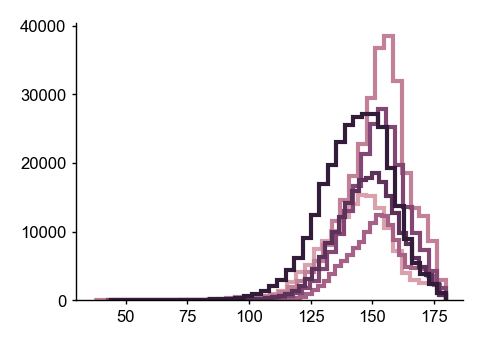

In [195]:
fig, ax = plt.subplots(1, 1, figsize=(2.5, 1.8))
for i in range(6):
    ax.hist((cohort_y)[cohort_mask[i] == 1, 0], histtype='step', color = colors.age_pal[ages[i]], lw = 1.5, bins = 40)

208.19539274058343 1.0529258585282735


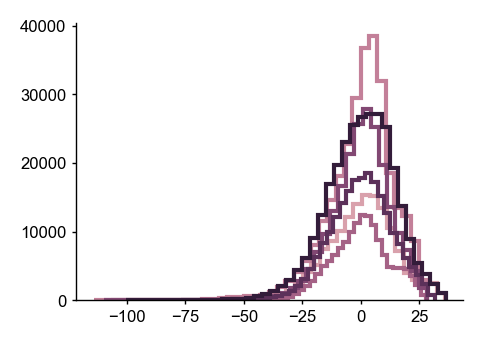

In [205]:
fig, ax = plt.subplots(1, 1, figsize=(2.5, 1.8))
j = 0
for i in range(6):
    x = (cohort_y - cohort_pred_jas)[cohort_mask[i] == 1, j]
    ax.hist(x, histtype='step', color = colors.age_pal[ages[i]], lw = 1.5, bins = 40)
x = (all_ja - cohort_pred_jas)[:, j]
print(x.var(), x.var() / all_ja[:, j].var())

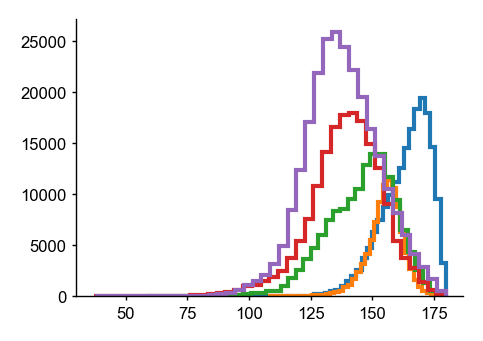

In [199]:
bhv_mask_arr = np.array(list(all_masks.values()))
fig, ax = plt.subplots(1, 1, figsize=(2.5, 1.8))
bhv_mask_arr = np.array(list(all_masks.values()))
for i in range(5):
    ax.hist(all_ja[bhv_mask_arr[i] == 1, 0], histtype='step', lw = 1.5, bins = 40)

128.19380511341745 0.6483264136168367


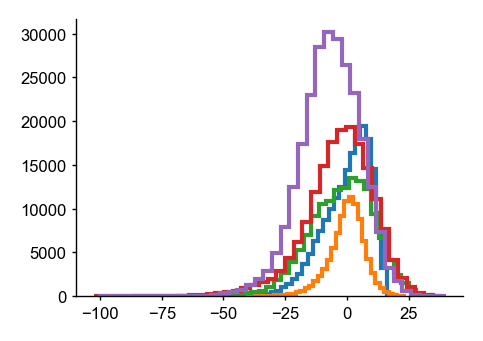

In [203]:
bhv_mask_arr = np.array(list(all_masks.values()))
fig, ax = plt.subplots(1, 1, figsize=(2.5, 1.8))
bhv_mask_arr = np.array(list(all_masks.values()))
j = 0
for i in range(5):
    x = (all_ja - bhv_pred_jas)[bhv_mask_arr[i] == 1, j]
    ax.hist(x, histtype='step', lw = 1.5, bins = 40)
x = (all_ja - bhv_pred_jas)[:, j]
print(x.var(), x.var() / all_ja[:, j].var())

### i. Time courses of inter keypoint distances and nose-to tail

/Users/kaifox/projects/mph/mph/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


../../plots/notebook/panels/v4/f3.1_session-halves/timecourses-bl-jas.pdf


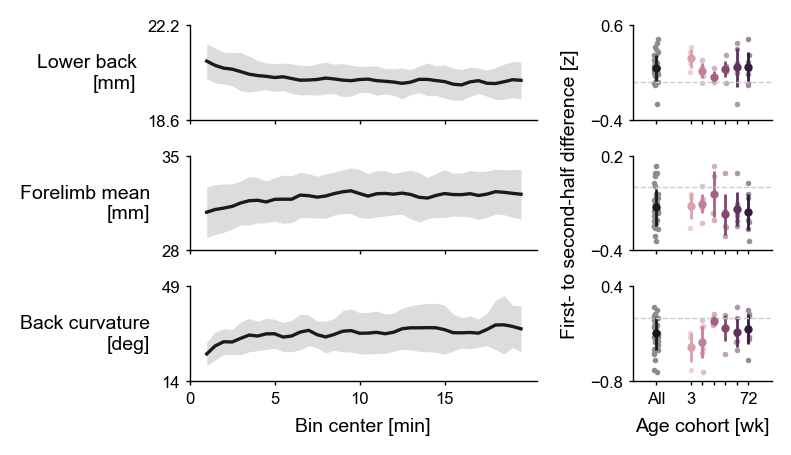

In [275]:
plot_sess = ["24wk_m4"]
lighten = [0.5, 0.5]
linewidth = [1.2, 1]

fig, ax = plt.subplots(3, 2, figsize=(4, 2.3), width_ratios=[2.5, 1])
summ_ax = ax[:, 1]
time_ax = ax[:, 0]

loback_ix = bone_names.index('lo back')
flmean_ix = [bone_names.index('left forelimb'), bone_names.index('right forelimb')]
backext_ix = joint_names.index('back')

ax = time_ax
for i, (s, lt, lw) in enumerate(zip(plot_sess, lighten, linewidth)):
    l = sessions
    lob = [bl[s][:min_nframes, loback_ix] for s in l]
    flm = [bl[s][:min_nframes, flmean_ix].mean(axis = -1) for s in l]
    bex = [180 - ja[s][:min_nframes, backext_ix] for s in l]
    a = s.split("_")[0].rstrip("wk")

    rolling_line(ax[0], frame_times, lob, 1800, colors.neutral, lt, lw=lw)
    rolling_line(ax[1], frame_times, flm, 1800, colors.neutral, lt, lw=lw)
    rolling_line(ax[2], frame_times, bex, 1800, colors.neutral, lt, lw=lw)

for a in ax:
    a.set_xticks([0, 5, 10, 15])
for a in ax[:-1]:
    a.set_xticklabels(["", "", "", ""])
vu.nticks(ax, 2, x=False)
vu.round_limits(ax, 0.6, x=False)

ax[0].set_ylabel("Lower back\n[mm]", rotation = 0, ha = 'right', va = 'center')
ax[1].set_ylabel("Forelimb mean\n[mm]", rotation = 0, ha = 'right', va = 'center')
ax[2].set_ylabel("Back curvature\n[deg]", rotation = 0, ha = 'right', va = 'center')
ax[-1].set_xlabel("Bin center [min]")

ax = summ_ax
half_zdiff = (
    lambda data, ix, sign=1: lambda s: zscore_dict(pull_ix(data, ix), sign)[s][half_slices[0]].mean()
    - zscore_dict(pull_ix(data, ix), sign)[s][half_slices[1]].mean()
)
normalize = lambda d, mean, std: {k: (v - mean) / std for k, v in d.items()}
zscore_dict = lambda d, sign=1: normalize(d, np.mean(np.concatenate(list(d.values()))), sign * np.std(np.concatenate(list(d.values()))))
pull_ix = lambda d, ix: {k: a[:, ix].mean(axis = -1) for k, a in d.items()}


for i, (data, ix, sgn) in enumerate(zip([bl, bl, ja], [[loback_ix], flmean_ix, [backext_ix]], [1, 1, -1])):
    group_and_summary_strips(
        ax[i],
        half_zdiff(data, ix, sgn),
        summary_color=colors.neutral,
        group_colors=colors.age_pal,
        x_ofs=3,
    )

for a in ax:
    a.axhline(0, color=colors.subtle, lw=0.5, ls="--")

ax[-1].set_xticklabels(["All"] + [ages[0]] + [""] * (len(ages) - 2) + [ages[-1]])
vu.nticks(ax, 2, x=False)
vu.round_limits(ax, 0.6, x=False)
ax[0].set_ylabel("First- to second-half difference [z]" + " " * 45, ha="center")
ax[-1].set_xlabel("Age cohort [wk]")

plotter.finalize(fig, 'timecourses-bl-jas', save = True, transparent = True, despine = False)